# 3.4 - Anomaly Detection

Four unsupervised anomaly-detection models run over the **pre-split v5** feature matrix,
fit on the training split and evaluated on the held-out test (validation) split:

- **IsolationForest** (sklearn)
- **COPOD** (PyOD - Copula-based)
- **Autoencoder** (PyTorch - reconstruction error)
- **Variational Autoencoder / VAE** (PyTorch - reconstruction-probability proxy)

We keep the v5 train/test split for its train/validation structure, but replace the (mostly
missing) `normalized_salary` column with **v6's regressed salaries** (joined on `job_id`),
which carry more signal than a median fill.

Workflow: fit the scaler and every model on **train only**, derive each model's anomaly
threshold from the train scores, then score the **test** split and do all inspection /
evaluation there. The `pay_period_BIWEEKLY` rows are dropped *before training* because they
destabilise the reconstruction models (see section 3.2).

## 1. Setup and Data Loading

In [68]:
# Imports and configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from pyod.models.copod import COPOD

from IPython.display import Image, display

sns.set_style("whitegrid")

# -- Paths --
# v5: 80/20 train/test split with job_id retained, but salary is the ORIGINAL
#     column (mostly NaN). We keep this split for the train/validation structure.
# v6: single combined file with normalized_salary fully imputed by a logged
#     regression run. We borrow those regressed salaries (joined on job_id) since
#     they carry more signal than a median fill.
V5_TRAIN = "../data/processed/v5/feature_matrix_train.csv"
V5_TEST = "../data/processed/v5/feature_matrix_test.csv"
V6_PATH = "../data/processed/v6/feature_matrix.csv"

# -- Anomaly detection config --
CONTAMINATION = 0.005  # expected fraction of anomalies
RANDOM_STATE = 42

# job_id is an identifier, NOT a feature - kept for row previews, excluded from X.
NON_FEATURE_COLS = ["job_id"]

In [69]:
# Load the pre-split train / validation (test) sets
df_train = pd.read_csv(V5_TRAIN)
df_test = pd.read_csv(V5_TEST)

print(f"Train shape: {df_train.shape}")
print(f"Test  shape: {df_test.shape}")

# Impute normalized_salary from v6's regressed values (joined on job_id).
# v6 ran a logged salary-regression model over every posting, so its salaries
# carry real signal instead of a flat median fill. v6 is unique on job_id and
# fully covers the v5 ids, so this is a clean lookup.
v6_salary = (
    pd.read_csv(V6_PATH, usecols=["job_id", "normalized_salary"])
    .set_index("job_id")["normalized_salary"]
)

for name, df in (("Train", df_train), ("Test", df_test)):
    missing_before = int(df["normalized_salary"].isna().sum())
    df["normalized_salary"] = df["job_id"].map(v6_salary)
    missing_after = int(df["normalized_salary"].isna().sum())
    print(f"{name}: normalized_salary NaNs {missing_before} -> {missing_after} "
          f"(filled from v6 regression)")

print(f"\nColumns:\n{list(df_train.columns)}")

Train shape: (98589, 45)
Test  shape: (24709, 45)
Train: normalized_salary NaNs 62448 -> 0 (filled from v6 regression)
Test: normalized_salary NaNs 15750 -> 0 (filled from v6 regression)

Columns:
['job_id', 'remote_allowed', 'normalized_salary', 'domain_similarity', 'domain_Construction/Real Estate', 'domain_Design', 'domain_Education', 'domain_Finance', 'domain_Government/Nonprofit', 'domain_Healthcare', 'domain_Human Resources', 'domain_Legal', 'domain_Manufacturing/Operations', 'domain_Media/Entertainment', 'domain_Retail/Hospitality', 'domain_Sales/Marketing', 'domain_Technology', 'domain_Unknown', 'title_length', 'desc_word_count', 'is_long_posting', 'listed_day_of_week', 'log_views', 'log_applies', 'apply_rate', 'pay_period_BIWEEKLY', 'pay_period_HOURLY', 'pay_period_MONTHLY', 'pay_period_WEEKLY', 'pay_period_YEARLY', 'formatted_work_type_Contract', 'formatted_work_type_Full-time', 'formatted_work_type_Internship', 'formatted_work_type_Other', 'formatted_work_type_Part-time', 'f

In [70]:
# Drop BIWEEKLY pay-period rows BEFORE training.
# pay_period_BIWEEKLY is a near-empty one-hot that hurts the Autoencoder / VAE
# (see section 3.2 for the before/after evidence). Drop from BOTH splits so the
# models neither train on nor are evaluated against the artifact.
def drop_biweekly(df, name):
    if "pay_period_BIWEEKLY" not in df.columns:
        print(f"{name}: 'pay_period_BIWEEKLY' column not found - nothing dropped.")
        return df.reset_index(drop=True)
    mask = df["pay_period_BIWEEKLY"] == True  # noqa: E712
    print(f"{name}: dropping {int(mask.sum())} BIWEEKLY rows "
          f"({len(df)} -> {len(df) - int(mask.sum())})")
    return df[~mask].reset_index(drop=True)

df_train = drop_biweekly(df_train, "Train")
df_test = drop_biweekly(df_test, "Test")

Train: dropping 9 BIWEEKLY rows (98589 -> 98580)
Test: dropping 0 BIWEEKLY rows (24709 -> 24709)


In [71]:
# Build feature matrices (exclude job_id) and report missing values
feature_cols = [c for c in df_train.columns if c not in NON_FEATURE_COLS]

X_train_raw = df_train[feature_cols].copy()
X_test_raw = df_test[feature_cols].copy()

missing_pct = X_train_raw.isna().mean().sort_values(ascending=False)
cols_with_missing = missing_pct[missing_pct > 0]
if len(cols_with_missing) > 0:
    print("Train columns with missing values (% missing):")
    print(cols_with_missing.to_string())
else:
    print("No missing values found in train.")

print(f"\nFeatures: {len(feature_cols)}")

Train columns with missing values (% missing):
apply_rate              0.811544
log_applies             0.811534
experience_level_ord    0.194248
log_views               0.013360

Features: 44


In [72]:
# Median fill (fit on TRAIN) + StandardScaler (fit on TRAIN), transform both.
# normalized_salary is already imputed from v6's regression above; median fill
# here only covers the remaining sparse columns (apply_rate, log_applies,
# experience_level_ord, log_views). Fitting both transforms on train only keeps
# the test split a genuine hold-out.
medians = X_train_raw.median()
X_train_filled = X_train_raw.fillna(medians)
X_test_filled = X_test_raw.fillna(medians)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_filled),
    columns=feature_cols,
    index=X_train_filled.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_filled),
    columns=feature_cols,
    index=X_test_filled.index,
)

print(f"Train feature matrix: {X_train_scaled.shape}")
print(f"Test  feature matrix: {X_test_scaled.shape}")

Train feature matrix: (98580, 44)
Test  feature matrix: (24709, 44)


## 2. Model Training

Each model is **fit on the training split**; the anomaly threshold is derived from the train
scores and then applied to the test (validation) split. The `results` dict collects every
model's **test** scores / labels / runtime for the inspection and evaluation sections.

In [73]:
results = {}  # name -> {"scores", "labels", "time"} on the TEST split

### 2.1 Isolation Forest

In [74]:
print("Running IsolationForest...")
t0 = time()
iso_model = IsolationForest(
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_estimators=200,
    n_jobs=-1,
)
iso_model.fit(X_train_scaled)  # fit on train

# Score / label the TEST split (threshold learned on train via offset_)
iso_scores = -iso_model.decision_function(X_test_scaled)  # higher = more anomalous
iso_labels = iso_model.predict(X_test_scaled)             # 1 = inlier, -1 = outlier
iso_labels_binary = (iso_labels == -1).astype(int)        # 1 = outlier, 0 = inlier
iso_time = time() - t0

results["IsolationForest"] = {
    "scores": iso_scores,
    "labels": iso_labels_binary,
    "time": iso_time,
}
print(f"  Done in {iso_time:.2f}s | test outliers: {iso_labels_binary.sum():,} "
      f"({iso_labels_binary.mean()*100:.2f}%)")

Running IsolationForest...
  Done in 1.83s | test outliers: 92 (0.37%)


### 2.2 COPOD

In [75]:
print("Running COPOD...")
t0 = time()
copod_model = COPOD(contamination=CONTAMINATION)
copod_model.fit(X_train_scaled)  # fit on train

# Score / label the TEST split (threshold_ learned on train)
copod_scores = copod_model.decision_function(X_test_scaled)
copod_labels = copod_model.predict(X_test_scaled)  # 0 = inlier, 1 = outlier
copod_time = time() - t0

results["COPOD"] = {
    "scores": copod_scores,
    "labels": copod_labels,
    "time": copod_time,
}
print(f"  Done in {copod_time:.2f}s | test outliers: {copod_labels.sum():,} "
      f"({copod_labels.mean()*100:.2f}%)")

Running COPOD...
  Done in 3.62s | test outliers: 119 (0.48%)


### 2.3 Autoencoder

A plain reconstruction autoencoder (`44 -> 64 -> 32 -> 16 -> 32 -> 64 -> 44`). Trained on the
train split to minimise MSE; the per-sample reconstruction error is the anomaly score. The
threshold is the `CONTAMINATION` percentile of the **train** errors, applied to the test errors.

In [76]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

n_features = X_train_scaled.shape[1]


class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

Using device: cpu


In [77]:
# Autoencoder training (on TRAIN)
EPOCHS = 50
BATCH_SIZE = 512
LR = 1e-3

X_train_tensor = torch.FloatTensor(X_train_scaled.values).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled.values).to(device)

dataset = TensorDataset(X_train_tensor, X_train_tensor)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = Autoencoder(n_features, latent_dim=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
criterion = nn.MSELoss(reduction="mean")

print(f"Training autoencoder: {n_features} -> 64 -> 32 -> 16 -> 32 -> 64 -> {n_features}")
print(f"Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | LR: {LR}\n")

t0 = time()
history = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch_x, _ in loader:
        recon = model(batch_x)
        loss = criterion(recon, batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    avg_loss = epoch_loss / len(dataset)
    history.append(avg_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss: {avg_loss:.6f}")

ae_train_time = time() - t0
print(f"\nTraining complete in {ae_train_time:.2f}s")

Training autoencoder: 44 -> 64 -> 32 -> 16 -> 32 -> 64 -> 44
Epochs: 50 | Batch size: 512 | LR: 0.001

  Epoch   1/50  loss: 0.708792
  Epoch  10/50  loss: 0.315385
  Epoch  20/50  loss: 0.268400
  Epoch  30/50  loss: 0.240698
  Epoch  40/50  loss: 0.230129
  Epoch  50/50  loss: 0.226284

Training complete in 78.04s


In [78]:
# Reconstruction error: threshold from TRAIN, applied to TEST
model.eval()
with torch.no_grad():
    ae_train_recon = model(X_train_tensor)
    ae_train_scores = ((X_train_tensor - ae_train_recon) ** 2).mean(dim=1).cpu().numpy()

    ae_test_recon = model(X_test_tensor)
    ae_scores = ((X_test_tensor - ae_test_recon) ** 2).mean(dim=1).cpu().numpy()

# Threshold = contamination percentile of TRAIN errors
threshold = np.percentile(ae_train_scores, 100 * (1 - CONTAMINATION))
ae_labels = (ae_scores >= threshold).astype(int)

results["Autoencoder"] = {
    "scores": ae_scores,
    "labels": ae_labels,
    "time": ae_train_time,
}

print(f"Train threshold (p{100*(1-CONTAMINATION):.1f}): {threshold:.6f}")
print(f"Test outliers flagged: {ae_labels.sum():,} ({ae_labels.mean()*100:.2f}%)")

Train threshold (p99.5): 0.643527
Test outliers flagged: 166 (0.67%)


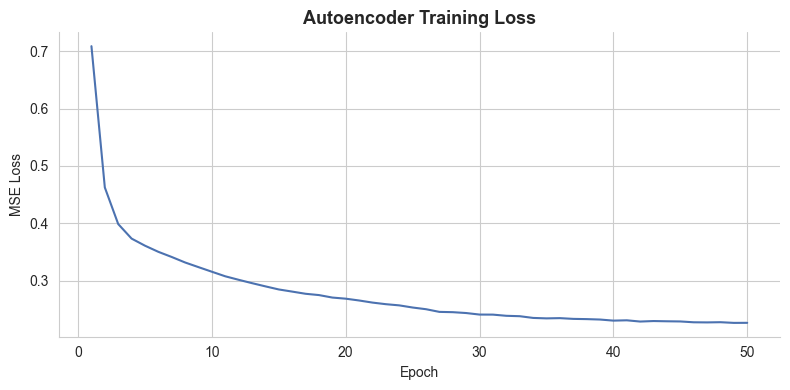

In [79]:
# Autoencoder training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), history, color="#4C72B0", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Autoencoder Training Loss", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### 2.4 VAE

A variational autoencoder: the encoder maps each input to a Gaussian latent posterior
`N(mu, sigma^2)`, `z` is sampled via the reparameterization trick, and training minimises the
negative ELBO (reconstruction MSE + KL to a standard-normal prior). The anomaly score is a
**reconstruction-probability proxy** - per-sample MSE averaged over `L_SAMPLES` stochastic
latent draws. Threshold is again the `CONTAMINATION` percentile of the **train** scores.

In [80]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


def vae_loss(recon, x, mu, logvar, beta=1.0):
    """Negative ELBO = reconstruction MSE + beta * KL(N(mu,sigma) || N(0,1))."""
    recon_loss = nn.functional.mse_loss(recon, x, reduction="mean")
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld, recon_loss, kld

In [81]:
# VAE training (on TRAIN; reuses the loader from the autoencoder section)
VAE_EPOCHS = 50
VAE_BATCH_SIZE = 512
VAE_LR = 1e-3
VAE_BETA = 1.0  # weight on the KL term (beta-VAE; 1.0 = standard VAE)

vae_model = VAE(n_features, latent_dim=16).to(device)
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=VAE_LR, weight_decay=1e-5)

print(f"Training VAE: {n_features} -> 64 -> 32 -> (mu,logvar=16) -> 32 -> 64 -> {n_features}")
print(f"Epochs: {VAE_EPOCHS} | Batch size: {VAE_BATCH_SIZE} | LR: {VAE_LR} | beta: {VAE_BETA}\n")

t0 = time()
vae_history = {"total": [], "recon": [], "kld": []}
for epoch in range(VAE_EPOCHS):
    vae_model.train()
    ep_total = ep_recon = ep_kld = 0.0
    for batch_x, _ in loader:
        recon, mu, logvar = vae_model(batch_x)
        loss, recon_loss, kld = vae_loss(recon, batch_x, mu, logvar, beta=VAE_BETA)
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        bs = batch_x.size(0)
        ep_total += loss.item() * bs
        ep_recon += recon_loss.item() * bs
        ep_kld += kld.item() * bs
    n = len(dataset)
    vae_history["total"].append(ep_total / n)
    vae_history["recon"].append(ep_recon / n)
    vae_history["kld"].append(ep_kld / n)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{VAE_EPOCHS}  total: {vae_history['total'][-1]:.6f}"
              f"  recon: {vae_history['recon'][-1]:.6f}  kld: {vae_history['kld'][-1]:.6f}")

vae_train_time = time() - t0
print(f"\nTraining complete in {vae_train_time:.2f}s")

Training VAE: 44 -> 64 -> 32 -> (mu,logvar=16) -> 32 -> 64 -> 44
Epochs: 50 | Batch size: 512 | LR: 0.001 | beta: 1.0

  Epoch   1/50  total: 0.998323  recon: 0.956042  kld: 0.042282
  Epoch  10/50  total: 0.778102  recon: 0.628392  kld: 0.149710
  Epoch  20/50  total: 0.740141  recon: 0.557279  kld: 0.182861
  Epoch  30/50  total: 0.723296  recon: 0.517286  kld: 0.206009
  Epoch  40/50  total: 0.699303  recon: 0.477368  kld: 0.221934
  Epoch  50/50  total: 0.686439  recon: 0.453760  kld: 0.232679

Training complete in 73.08s


Train threshold (p99.5): 2.216485
Test outliers flagged: 137 (0.55%)


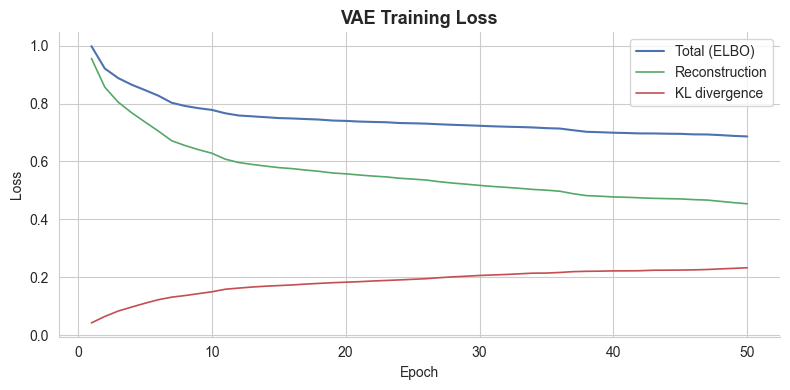

In [82]:
# VAE anomaly score (reconstruction-probability proxy): threshold from TRAIN, applied to TEST
L_SAMPLES = 10

vae_model.eval()
with torch.no_grad():
    def vae_recon_error(x_tensor):
        err_sum = torch.zeros(x_tensor.size(0), device=device)
        for _ in range(L_SAMPLES):
            recon, _, _ = vae_model(x_tensor)
            err_sum += ((x_tensor - recon) ** 2).mean(dim=1)
        return (err_sum / L_SAMPLES).cpu().numpy()

    vae_train_scores = vae_recon_error(X_train_tensor)
    vae_scores = vae_recon_error(X_test_tensor)

vae_threshold = np.percentile(vae_train_scores, 100 * (1 - CONTAMINATION))
vae_labels = (vae_scores >= vae_threshold).astype(int)

results["VAE"] = {
    "scores": vae_scores,
    "labels": vae_labels,
    "time": vae_train_time,
}

print(f"Train threshold (p{100*(1-CONTAMINATION):.1f}): {vae_threshold:.6f}")
print(f"Test outliers flagged: {vae_labels.sum():,} ({vae_labels.mean()*100:.2f}%)")

# VAE training loss curves (total / reconstruction / KL)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, VAE_EPOCHS + 1), vae_history["total"], color="#4C72B0", linewidth=1.5, label="Total (ELBO)")
ax.plot(range(1, VAE_EPOCHS + 1), vae_history["recon"], color="#55A868", linewidth=1.2, label="Reconstruction")
ax.plot(range(1, VAE_EPOCHS + 1), vae_history["kld"], color="#C44E52", linewidth=1.2, label="KL divergence")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("VAE Training Loss", fontsize=13, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [83]:
# Per-model summary on the TEST (validation) split
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        "Model": name,
        "Outliers": int(res["labels"].sum()),
        "Outlier %": f"{res['labels'].mean() * 100:.2f}%",
        "Runtime (s)": f"{res['time']:.2f}",
        "Score Mean": f"{res['scores'].mean():.4f}",
        "Score Std": f"{res['scores'].std():.4f}",
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

          Model  Outliers Outlier % Runtime (s) Score Mean Score Std
IsolationForest        92     0.37%        1.83    -0.1128    0.0355
          COPOD       119     0.48%        3.62    20.2573    5.0323
    Autoencoder       166     0.67%       78.04     0.1060    0.1193
            VAE       137     0.55%       73.08     0.4532    0.3601


## 3. Manual Inspection of Top Outliers

All inspection below is on the **test (validation)** split. `df_test` was already
BIWEEKLY-filtered and index-reset in section 1, so the score arrays in `results` align
positionally to its rows.

### 3.1 Per-Model Top Outliers

For each model, the rows with the highest anomaly score (most anomalous). `job_id` is placed
first so each outlier traces back to its posting.

In [96]:
TOP_N = 10
n_models = len(results)

if "job_id" not in df_anomaly.columns:
    print("WARNING: 'job_id' not in df_anomaly — load a version that retains it (v5/v6) "
          "to trace consensus anomalies back to postings.\n")

# Scale-invariant strength: mean percentile rank of the per-model anomaly scores
score_cols = [f"{name.lower()}_score" for name in results]
df_anomaly["mean_score_pct"] = df_anomaly[score_cols].rank(pct=True).mean(axis=1)

n_agree = n_models
in_tier = df_anomaly["outlier_votes"] == n_agree
tier = df_anomaly[in_tier].sort_values("mean_score_pct", ascending=False).head(TOP_N).copy()

label = "all" if n_agree == n_models else f"exactly {n_agree}"
print(f"\n{'=' * 80}\nConsensus anomalies — {label} of {n_models} models agree "
        f"({int(in_tier.sum()):,} total, showing top {len(tier)})\n{'=' * 80}")


if "job_id" in tier.columns:
    tier.insert(0, "job_id", tier.pop("job_id"))  # job_id first
display(tier.T)



Consensus anomalies — all of 4 models agree (6 total, showing top 6)


,10485,15757,8056,18563,8057,5024
job_id,3887114364,3903466857,3885115131,3902757169,3904367799,3902365634
remote_allowed,1,1,1,1,1,1
normalized_salary,112848.0,57000.0,54049.607073,70720.0,68640.0,12000.0
domain_similarity,0.6686,0.8515,0.6716,0.4297,0.7917,0.5347
domain_Construction/Real Estate,False,False,False,False,False,False
domain_Design,False,False,False,True,False,False
domain_Education,False,False,False,False,False,True
domain_Finance,False,False,False,False,False,False
domain_Government/Nonprofit,False,False,False,False,False,False
domain_Healthcare,False,False,False,False,False,False


#### Key Patterns Observed

- **4 of 6** are long postings (60+ days) with unusually high apply rates (max 0.57)
- **2 of 6** are internships with incorrect work type classifications  
- **1 posting** has an extremely low normalized salary of 12k

These point to both data quality issues and genuinely atypical market listings.

### 3.2 Biweekly Pay Period Artifact

`pay_period_BIWEEKLY` is a near-empty one-hot column (only a handful of postings in the entire
dataset use a biweekly pay period). Those few extreme, sparsely-populated rows act as a
degenerate signal for the reconstruction models: **including them measurably hurt the
Autoencoder and the VAE**, distorting their reconstruction-error distributions and skewing the
learned anomaly threshold so that genuine outliers were crowded out by the biweekly rows. The
tree- and copula-based models (IsolationForest, COPOD) were far less sensitive.

For that reason the BIWEEKLY rows are dropped **before model training** (done in section 1).
The figures below contrast each reconstruction model's score distribution **with** vs.
**without** the biweekly rows - the "without" versions are cleaner and better separated, which
is what motivated the drop.

Autoencoder - WITH biweekly rows:


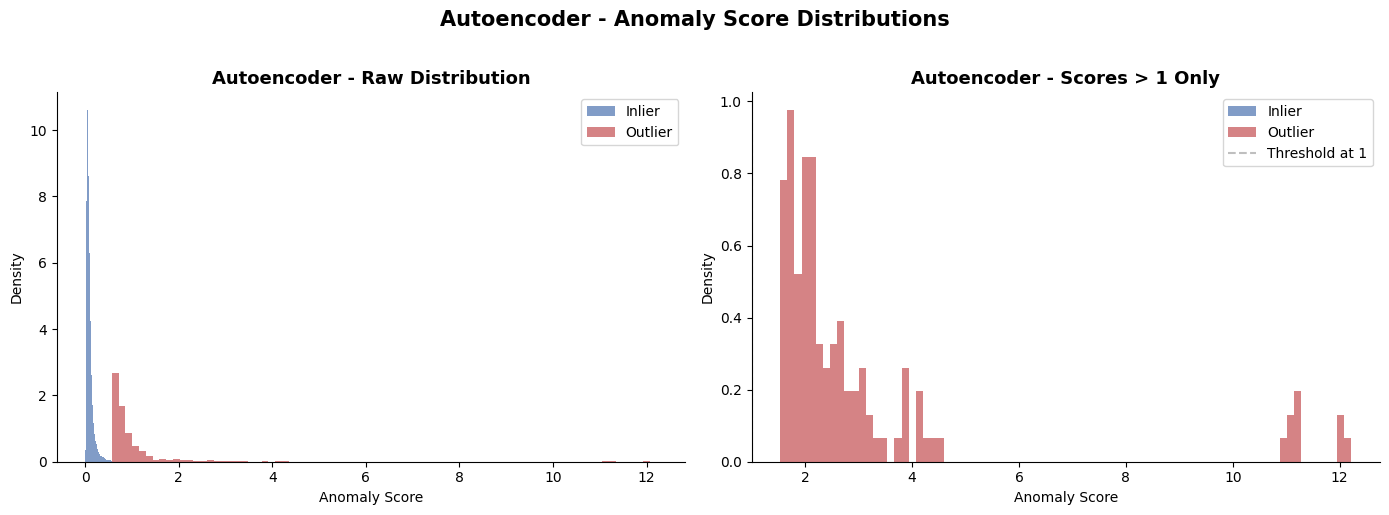

Autoencoder - WITHOUT biweekly rows (used for training):


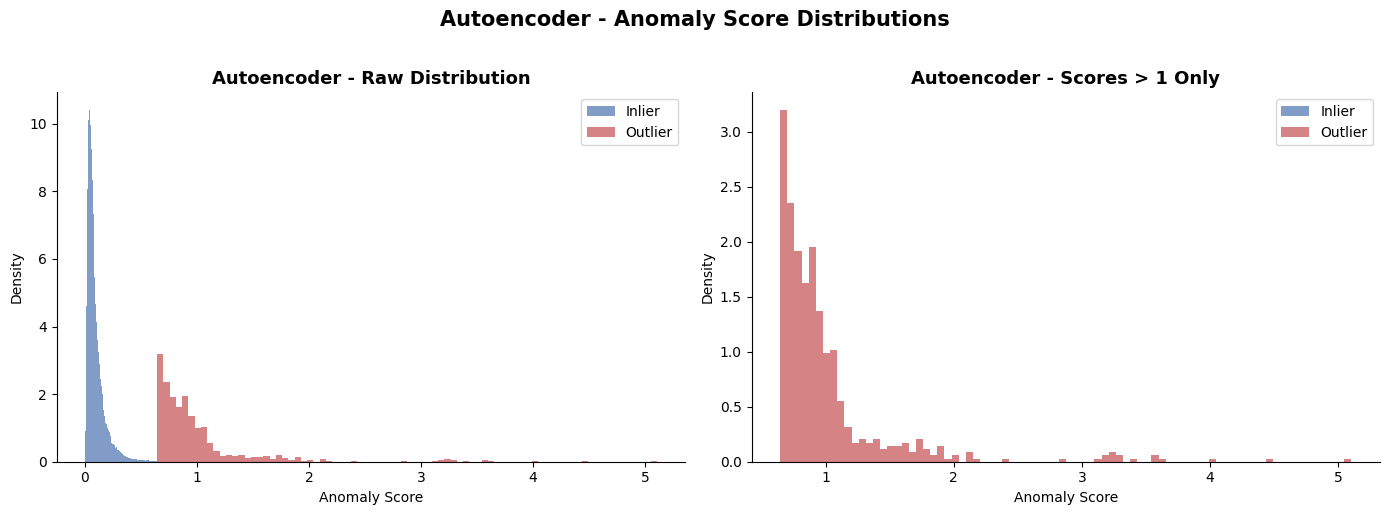

In [85]:
# Autoencoder: with vs. without the biweekly rows
print("Autoencoder - WITH biweekly rows:")
display(Image(filename="../artifacts/autoencoder with biweek rows.png"))
print("Autoencoder - WITHOUT biweekly rows (used for training):")
display(Image(filename="../artifacts/autoencoder without biweek rows.png"))

VAE - WITH biweekly rows:


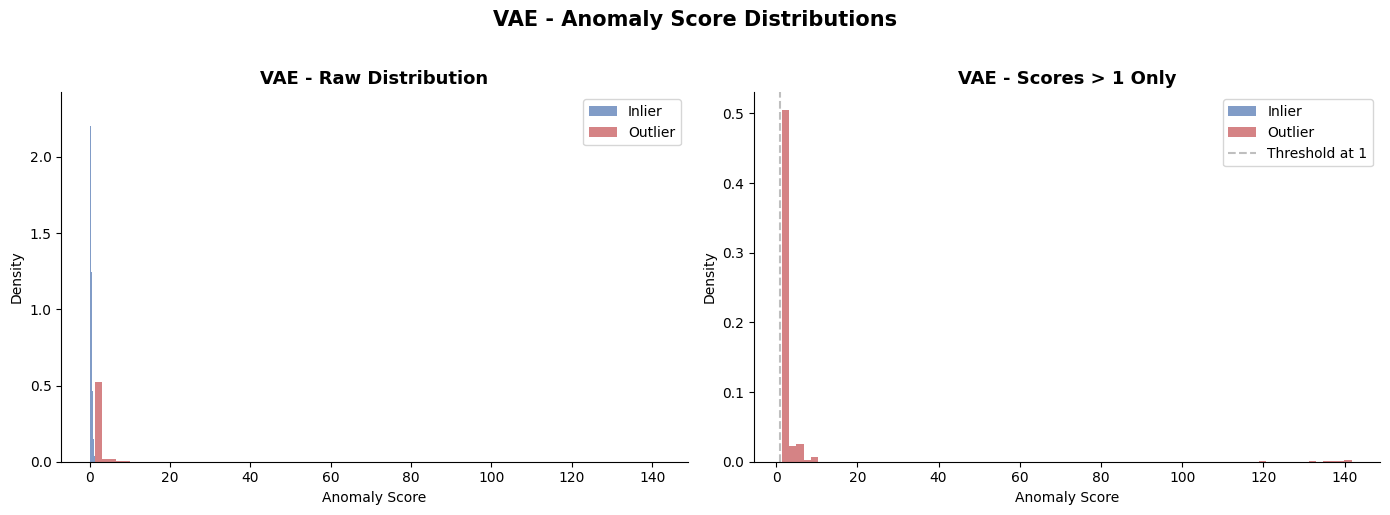

VAE - WITHOUT biweekly rows (used for training):


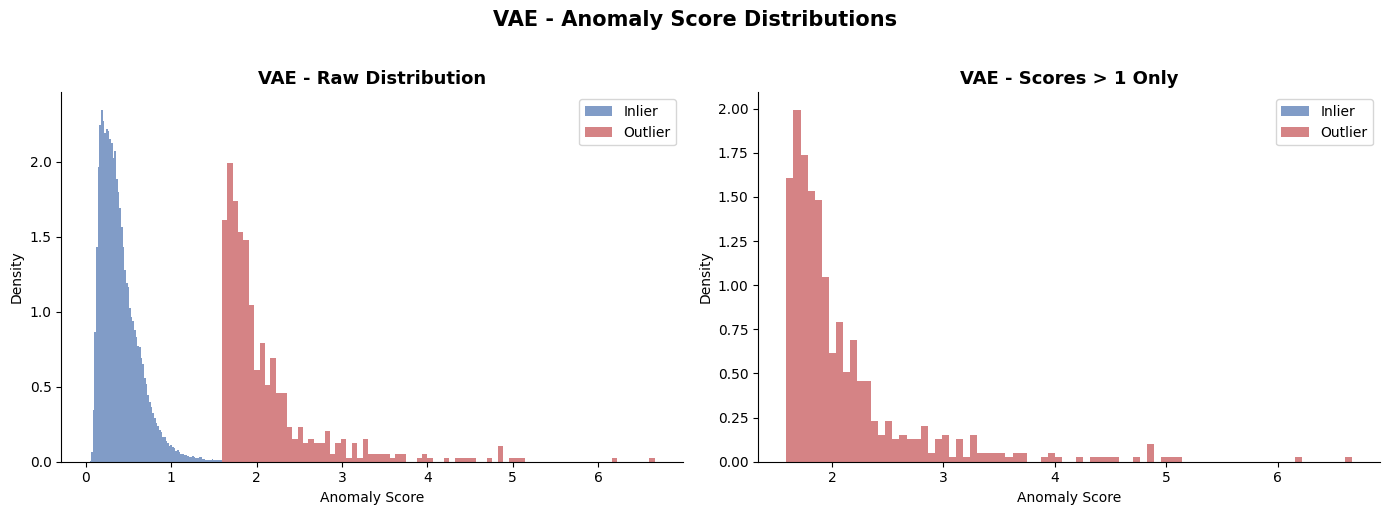

In [86]:
# VAE: with vs. without the biweekly rows
print("VAE - WITH biweekly rows:")
display(Image(filename="../artifacts/vae with biweek rows.png"))
print("VAE - WITHOUT biweekly rows (used for training):")
display(Image(filename="../artifacts/vae without biweek rows.png"))

## 4. Validation Set Evaluation

Score distributions, model agreement, and overlap - all computed on the **test (validation)**
split scores stored in `results`.

### 4.1 Score Distributions

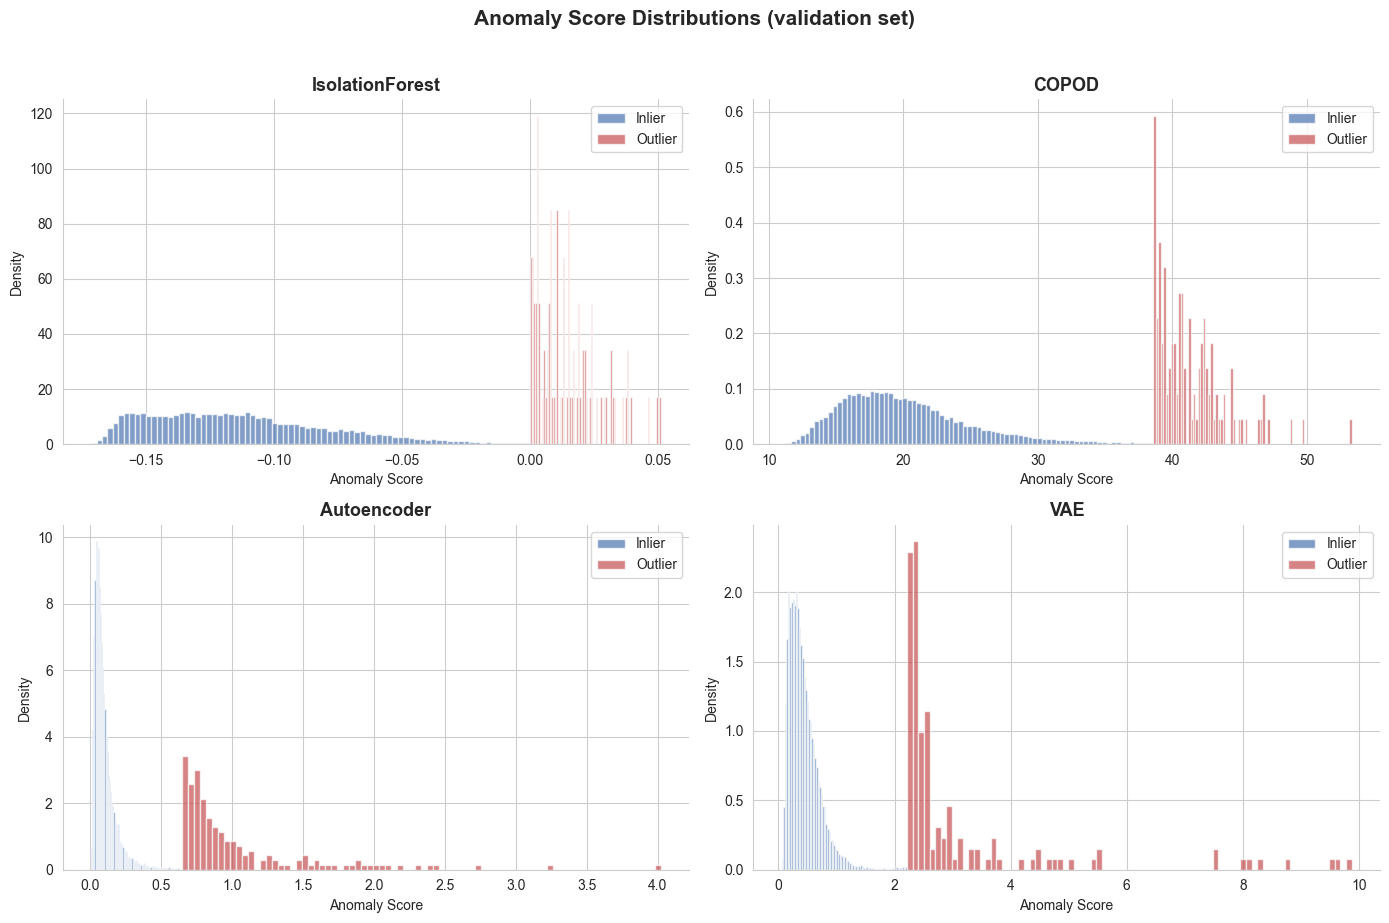

In [87]:
n_models = len(results)
ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (name, res) in zip(axes, results.items()):
    scores = res["scores"]
    labels = res["labels"]
    ax.hist(scores[labels == 0], bins=80, alpha=0.7, label="Inlier", color="#4C72B0", density=True)
    ax.hist(scores[labels == 1], bins=80, alpha=0.7, label="Outlier", color="#C44E52", density=True)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Anomaly Score")
    ax.set_ylabel("Density")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle("Anomaly Score Distributions (validation set)", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 4.2 Model Agreement (ensemble consensus)

In [88]:
df_labels = pd.DataFrame({name: res["labels"] for name, res in results.items()})
n_models = df_labels.shape[1]
df_labels["agreement_count"] = df_labels.sum(axis=1)

agreement_dist = df_labels["agreement_count"].value_counts().sort_index()
print("Number of models flagging each validation point as outlier:\n")
for count, n_points in agreement_dist.items():
    pct = n_points / len(df_labels) * 100
    print(f"  {count} model(s): {n_points:>6,} points ({pct:.2f}%)")

high_confidence_mask = df_labels["agreement_count"] == n_models
n_high = high_confidence_mask.sum()
print(f"\nHigh-confidence anomalies (all {n_models} models agree): "
      f"{n_high:,} ({n_high / len(df_labels) * 100:.2f}%)")

at_least_2_mask = df_labels["agreement_count"] >= 2
n_at_least_2 = at_least_2_mask.sum()
print(f"Moderate-confidence anomalies (>= 2 models):    "
      f"{n_at_least_2:,} ({n_at_least_2 / len(df_labels) * 100:.2f}%)")

Number of models flagging each validation point as outlier:

  0 model(s): 24,324 points (98.44%)
  1 model(s):    281 points (1.14%)
  2 model(s):     85 points (0.34%)
  3 model(s):     13 points (0.05%)
  4 model(s):      6 points (0.02%)

High-confidence anomalies (all 4 models agree): 6 (0.02%)
Moderate-confidence anomalies (>= 2 models):    104 (0.42%)


### 4.3 Overlap Analysis

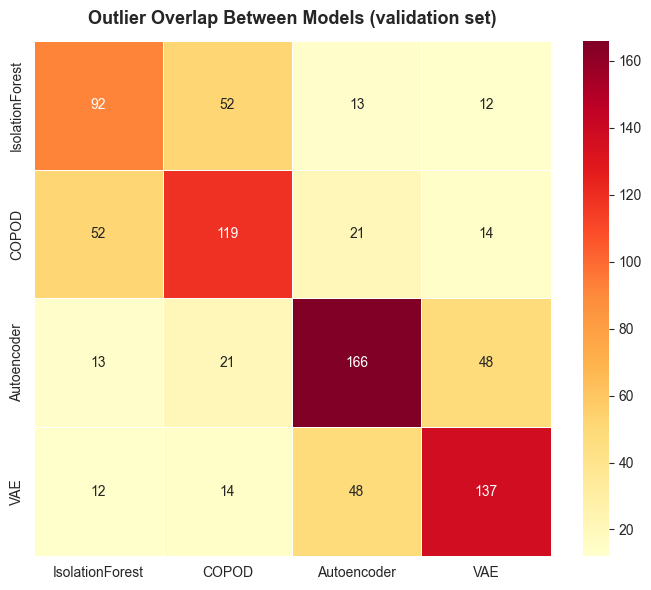

In [89]:
model_names = list(results.keys())
overlap_matrix = pd.DataFrame(
    np.zeros((len(model_names), len(model_names)), dtype=int),
    index=model_names,
    columns=model_names,
)
for i, name_a in enumerate(model_names):
    for j, name_b in enumerate(model_names):
        mask_a = df_labels[name_a] == 1
        mask_b = df_labels[name_b] == 1
        overlap_matrix.iloc[i, j] = (mask_a & mask_b).sum()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(overlap_matrix, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Outlier Overlap Between Models (validation set)", fontsize=13, fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

## 5. Summary: Anomaly Detection Results

### Model Agreement and Detection Strategy

Across the 4 anomaly detection models (IsolationForest, COPOD, Autoencoder, VAE), agreement is sparse and follows a clear pattern: the vast majority of validation records (98.44%) are flagged by no models, indicating strong model consensus on normality.

Agreement distribution:
- **0 models**: 24,324 points (98.44%) - Clear inliers
- **1 model**: 281 points (1.14%) - Isolated flagged points
- **2 models**: 85 points (0.34%) - Moderate agreement
- **3 models**: 13 points (0.05%) - Strong agreement
- **4 models**: 6 points (0.02%) - Consensus anomalies

### Selected Detection Threshold

Given this sparse agreement landscape, we adopt a **majority voting system requiring 2+ model agreement**. This yields:

- **Moderate-confidence anomalies (2+ models)**: 104 records (0.42%)
- **High-confidence anomalies (4 models)**: 6 records (0.02%)

This threshold balances sensitivity (catching real anomalies) with specificity (avoiding false positives driven by single models).